## Imports 

In [1]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.transforms import functional as TF
from PIL import Image
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from math import log10
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cuda


## U-Net Model

In [2]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=1):  # NEW: Flexible input channels
        super().__init__()

        # Encoder
        self.d1 = ConvBlock(in_channels, 32)  # Changed from hardcoded "1"
        self.p1 = nn.MaxPool2d(2)

        self.d2 = ConvBlock(32, 64)
        self.p2 = nn.MaxPool2d(2)

        self.d3 = ConvBlock(64, 128)
        self.p3 = nn.MaxPool2d(2)

        self.d4 = ConvBlock(128, 256)
        self.p4 = nn.MaxPool2d(2)

        # Bottleneck
        self.bn = ConvBlock(256, 512)

        # Decoder
        self.u4 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.c4 = ConvBlock(256 + 256, 256)

        self.u3 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.c3 = ConvBlock(128 + 128, 128)

        self.u2 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.c2 = ConvBlock(64 + 64, 64)

        self.u1 = nn.ConvTranspose2d(64, 32, 2, 2)
        self.c1 = ConvBlock(32 + 32, 32)

        self.out = nn.Conv2d(32, in_channels, 1)  # Output matches input channels

    def forward(self, x):
        d1 = self.d1(x)
        p1 = self.p1(d1)

        d2 = self.d2(p1)
        p2 = self.p2(d2)

        d3 = self.d3(p2)
        p3 = self.p3(d3)

        d4 = self.d4(p3)
        p4 = self.p4(d4)

        bn = self.bn(p4)

        u4 = self.u4(bn)
        c4 = self.c4(torch.cat([u4, d4], dim=1))

        u3 = self.u3(c4)
        c3 = self.c3(torch.cat([u3, d3], dim=1))

        u2 = self.u2(c3)
        c2 = self.c2(torch.cat([u2, d2], dim=1))

        u1 = self.u1(c2)
        c1 = self.c1(torch.cat([u1, d1], dim=1))

        return self.out(c1)


## Phase-1 Corruption Functions 

In [5]:
def add_gaussian_noise(img, sigma=0.03):
    noise = torch.randn_like(img, dtype=torch.float32) * sigma
    return torch.clamp(img + noise, 0.0, 1.0)

def add_gaussian_blur(img, kernel=5, sigma=1.0):
    img_np = img.squeeze().cpu().numpy().astype(np.float32)
    img_np = cv2.GaussianBlur(img_np, (kernel, kernel), sigma)
    return torch.tensor(img_np, dtype=torch.float32).unsqueeze(0)

def add_bias_field(img, strength=0.15):
    h, w = img.shape[-2:]
    bias = np.random.randn(h, w).astype(np.float32)
    bias = cv2.GaussianBlur(bias, (0, 0), sigmaX=32)
    bias = bias / (np.max(np.abs(bias)) + 1e-6)
    bias = 1.0 + strength * bias
    img_np = img.squeeze().cpu().numpy().astype(np.float32)
    img_np = img_np * bias
    img_np = np.clip(img_np, 0.0, 1.0)
    return torch.tensor(img_np, dtype=torch.float32).unsqueeze(0)

def corrupt_patch(img):
    img = img.float()
    if torch.rand(1) < 0.7:
        img = add_gaussian_noise(img)
    if torch.rand(1) < 0.5:
        img = add_gaussian_blur(img)
    if torch.rand(1) < 0.5:
        img = add_bias_field(img)
    return img.float()


## Phase-1 Dataset 

In [6]:
class Phase1Dataset(Dataset):
    def __init__(self, image_dir, patch_size=128, samples_per_image=50):
        self.image_dir = image_dir
        self.patch_size = patch_size
        self.samples = []

        image_files = sorted([
            f for f in os.listdir(image_dir)
            if f.lower().endswith((".tif", ".png", ".jpg", ".jpeg"))
        ])

        for fname in image_files:
            path = os.path.join(image_dir, fname)
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = img.astype(np.float32) / 255.0
            h, w = img.shape

            for _ in range(samples_per_image):
                y = np.random.randint(0, h - patch_size + 1)
                x = np.random.randint(0, w - patch_size + 1)
                patch = img[y:y+patch_size, x:x+patch_size]
                self.samples.append(patch)

        print(f"Phase 1 patches created: {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        clean = torch.tensor(self.samples[idx], dtype=torch.float32).unsqueeze(0)
        corrupted = corrupt_patch(clean.clone())
        return corrupted, clean


## Phase-1 Training 

In [7]:
# Configuration
PHASE1_IMAGE_DIR = r"C:\Users\User\OneDrive\Documents\MATLAB\Matlab Data\solder_ball_data"

# Create Phase 1 dataset
train_ds = Phase1Dataset(PHASE1_IMAGE_DIR, patch_size=128, samples_per_image=50)
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=0, pin_memory=True)

# Initialize model for Phase 1 (grayscale, 1 channel)
model = UNet(in_channels=1).to(device)
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 30
model.train()

for epoch in range(1, EPOCHS + 1):
    running_loss = 0
    
    for inp, tar in tqdm(train_loader, desc=f"Epoch {epoch}"):
        inp, tar = inp.to(device), tar.to(device)
        
        optimizer.zero_grad()
        out = model(inp)
        loss = criterion(out, tar)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    print(f"Epoch {epoch:02d} L1 Loss: {running_loss/len(train_loader):.4f}")

torch.save(model.state_dict(), "phase1_geom.pth")
print("Phase 1 complete. Saved phase1_geom.pth")


Phase 1 patches created: 5600


Epoch 1: 100%|███████████████████████████████████████████████████████████████████████| 700/700 [01:03<00:00, 10.95it/s]


Epoch 01 L1 Loss: 0.0487


Epoch 2: 100%|███████████████████████████████████████████████████████████████████████| 700/700 [01:04<00:00, 10.89it/s]


Epoch 02 L1 Loss: 0.0184


...

Epoch 28 L1 Loss: 0.0166


Epoch 29: 100%|██████████████████████████████████████████████████████████████████████| 700/700 [01:11<00:00,  9.84it/s]


Epoch 29 L1 Loss: 0.0165


Epoch 30: 100%|██████████████████████████████████████████████████████████████████████| 700/700 [01:04<00:00, 10.87it/s]

Epoch 30 L1 Loss: 0.0165
Phase 1 complete. Saved phase1_geom.pth


## Phase-2 Dataset

In [8]:
class ISTDDataset(Dataset):
    """
    NEW: Loads ISTD paired shadow/clean RGB images
    """
    def __init__(self, root_dir, transform=None, mode='train'):
        self.root_dir = root_dir
        self.transform = transform
        self.mode = mode
        
        # ISTD folder structure: train/train_A (shadow), train/train_C (clean)
        self.shadow_dir = os.path.join(root_dir, mode, f'{mode}_A')
        self.clean_dir = os.path.join(root_dir, mode, f'{mode}_C')
        
        # Get matching filenames
        self.image_names = sorted(os.listdir(self.shadow_dir))

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        
        shadow_path = os.path.join(self.shadow_dir, img_name)
        clean_path = os.path.join(self.clean_dir, img_name)
        
        # Load as RGB (3 channels)
        shadow_img = Image.open(shadow_path).convert("RGB")
        clean_img = Image.open(clean_path).convert("RGB")
        
        if self.transform:
            shadow_img = self.transform(shadow_img)
            clean_img = self.transform(clean_img)
            
        return shadow_img, clean_img


## Phase-2 Setup

In [10]:
# Configuration
BATCH_SIZE = 8
IMG_SIZE = 256

# ISTD Transforms (RGB normalization)
istd_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),  # Converts to [0,1] float
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet normalization
])

# Create ISTD Dataset
ISTD_ROOT = r'C:\Users\User\OneDrive\Documents\Shadow Removal\Shadow_Removal\istd\ISTD_Dataset' 
phase2_dataset = ISTDDataset(root_dir=ISTD_ROOT, mode='train', transform=istd_transforms)
phase2_loader = DataLoader(phase2_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

print(f"Phase 2 Dataset: {len(phase2_dataset)} samples")


Phase 2 Dataset: 1330 samples


## Phase-2 Training 

In [11]:
# Load Phase 1 weights
model = UNet(in_channels=3).to(device)  # NEW: 3 channels for RGB

# We can't directly load Phase 1 weights (1 channel) into Phase 2 model (3 channels)
# So we initialize fresh for Phase 2 

print("Initialized Phase 2 model (RGB, 3 channels)")

criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)  # Lower LR
EPOCHS = 25

model.train()

for epoch in range(1, EPOCHS + 1):
    running_loss = 0
    
    for inp, tar in tqdm(phase2_loader, desc=f"Epoch {epoch}/{EPOCHS}"):
        inp, tar = inp.to(device), tar.to(device)
        
        optimizer.zero_grad()
        out = model(inp)
        loss = criterion(out, tar)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    print(f"Epoch {epoch:02d} Loss: {running_loss/len(phase2_loader):.4f}")

torch.save(model.state_dict(), "phase2_istd.pth")
print("Phase 2 complete. Saved phase2_istd.pth")


Initialized Phase 2 model (RGB, 3 channels)


Epoch 1/25: 100%|████████████████████████████████████████████████████████████████████| 167/167 [03:49<00:00,  1.37s/it]


Epoch 01 Loss: 0.4342


Epoch 2/25: 100%|████████████████████████████████████████████████████████████████████| 167/167 [03:01<00:00,  1.09s/it]


Epoch 02 Loss: 0.3459


...

Epoch 23 Loss: 0.1836


Epoch 24/25: 100%|███████████████████████████████████████████████████████████████████| 167/167 [02:55<00:00,  1.05s/it]


Epoch 24 Loss: 0.1761


Epoch 25/25: 100%|███████████████████████████████████████████████████████████████████| 167/167 [02:55<00:00,  1.05s/it]

Epoch 25 Loss: 0.1720
Phase 2 complete. Saved phase2_istd.pth


## Phase-2 Retraining on grayscale ISTD

In [4]:
# ===========================
# Phase 2: ISTD but GRAYSCALE
# ===========================

class ISTDDatasetGrayscale(Dataset):
    """
    MODIFIED: Convert ISTD to grayscale to match Phase 3
    """
    def __init__(self, root_dir, transform=None, mode='train'):
        self.root_dir = root_dir
        self.transform = transform
        self.mode = mode
        
        self.shadow_dir = os.path.join(root_dir, mode, f'{mode}_A')
        self.clean_dir = os.path.join(root_dir, mode, f'{mode}_C')
        self.image_names = sorted(os.listdir(self.shadow_dir))

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        
        shadow_path = os.path.join(self.shadow_dir, img_name)
        clean_path = os.path.join(self.clean_dir, img_name)
        
        # Load as RGB then convert to grayscale
        shadow_img = Image.open(shadow_path).convert("L")  # ← CHANGED: "L" = grayscale
        clean_img = Image.open(clean_path).convert("L")    # ← CHANGED
        
        if self.transform:
            shadow_img = self.transform(shadow_img)
            clean_img = self.transform(clean_img)
            
        return shadow_img, clean_img


# Grayscale transforms (NO RGB normalization)
istd_transforms_gray = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),  # Already [0,1]
])

# Create grayscale ISTD dataset
ISTD_ROOT = r'C:\Users\User\OneDrive\Documents\Shadow Removal\Shadow_Removal\istd\ISTD_Dataset' 
phase2_dataset = ISTDDatasetGrayscale(root_dir=ISTD_ROOT, mode='train', transform=istd_transforms_gray)
phase2_loader = DataLoader(phase2_dataset, batch_size=8, shuffle=True, num_workers=0)

print(f"Phase 2 Dataset (Grayscale): {len(phase2_dataset)} samples")

# Load Phase 1 weights (now both are 1-channel!)
model = UNet(in_channels=1).to(device)
ckpt = torch.load("phase1_geom.pth", map_location=device)
model.load_state_dict(ckpt)  # ← Direct load, no filtering!
model.train()

print("Loaded Phase 1 weights into Phase 2 model")

# Train Phase 2
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)
EPOCHS = 30

for epoch in range(1, EPOCHS + 1):
    running_loss = 0
    
    for inp, tar in tqdm(phase2_loader, desc=f"Epoch {epoch}/{EPOCHS}"):
        inp, tar = inp.to(device), tar.to(device)
        
        optimizer.zero_grad()
        out = model(inp)
        loss = criterion(out, tar)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    print(f"Epoch {epoch:02d} Loss: {running_loss/len(phase2_loader):.4f}")

torch.save(model.state_dict(), "phase2_istd_grayscale.pth")
print("Phase 2 (Grayscale) complete!")


Phase 2 Dataset (Grayscale): 1330 samples


C:\Users\User\AppData\Local\Temp\ipykernel_15664\3241592022.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load("phase1_geom.pth", map_location=device)


Loaded Phase 1 weights into Phase 2 model


Epoch 1/30: 100%|████████████████████████████████████████████████████████████████████| 167/167 [03:05<00:00,  1.11s/it]


Epoch 01 Loss: 0.0671


...

Epoch 28 Loss: 0.0242


Epoch 29/30: 100%|███████████████████████████████████████████████████████████████████| 167/167 [02:57<00:00,  1.06s/it]


Epoch 29 Loss: 0.0232


Epoch 30/30: 100%|███████████████████████████████████████████████████████████████████| 167/167 [02:54<00:00,  1.04s/it]

Epoch 30 Loss: 0.0226
Phase 2 (Grayscale) complete!


In [4]:
# Cell 3: Verify Phase 2 Model Exists
import os

if os.path.exists("phase2_istd_grayscale.pth"):
    print("✓ Phase 2 model found: phase2_istd_grayscale.pth")
    
    # Check file size
    size_mb = os.path.getsize("phase2_istd_grayscale.pth") / (1024 * 1024)
    print(f"  File size: {size_mb:.2f} MB")
    
    # Quick load test
    try:
        ckpt = torch.load("phase2_istd_grayscale.pth", map_location="cpu", weights_only=False)
        print(f"  Contains {len(ckpt)} model parameters")
        print("\n✓ Phase 2 model is valid and ready to use!")
    except Exception as e:
        print(f"  Error loading model: {e}")
else:
    print(" Phase 2 model NOT found. You need to retrain.")


✓ Phase 2 model found: phase2_istd_grayscale.pth
  File size: 29.62 MB
  Contains 46 model parameters

✓ Phase 2 model is valid and ready to use!


## Phase-3 Datasets

In [5]:
class PatchDataset(Dataset):
    def __init__(self, root_dir, split, augment=False):
        self.augment = augment
        self.input_dir = os.path.join(root_dir, split, "input")
        self.target_dir = os.path.join(root_dir, split, "target")
        self.files = sorted(os.listdir(self.input_dir))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]
        
        inp = cv2.imread(os.path.join(self.input_dir, fname), 0).astype(np.float32) / 255.0
        tar = cv2.imread(os.path.join(self.target_dir, fname), 0).astype(np.float32) / 255.0
        
        inp = torch.tensor(inp, dtype=torch.float32).unsqueeze(0)
        tar = torch.tensor(tar, dtype=torch.float32).unsqueeze(0)
        
        if self.augment:
            if torch.rand(1) < 0.5:
                inp = TF.hflip(inp)
                tar = TF.hflip(tar)
            if torch.rand(1) < 0.5:
                inp = TF.vflip(inp)
                tar = TF.vflip(tar)
        
        return inp, tar


## Phase-3 Training (Load Phase-2 Model)

In [6]:
# ===========================
# PHASE 3: TRI SPECIALIZATION
# ===========================

# Load Phase 2 GRAYSCALE weights (DIRECT LOAD - NO FILTERING!)
model = UNet(in_channels=1).to(device)
ckpt = torch.load("phase2_istd_grayscale.pth", map_location=device, weights_only=False)
model.load_state_dict(ckpt)  # ← Perfect 1:1 transfer!
model.train()

print("✓ Loaded Phase 2 grayscale shadow-aware weights")
print("  All layers transferred successfully (1-channel → 1-channel)")

# Phase 3 dataset 
train_ds = PatchDataset(
    r"C:\Users\User\OneDrive\Documents\Shadow Removal\Shadow_Removal\dataset_v2", 
    "train", 
    augment=True
)
val_ds = PatchDataset(
    r"C:\Users\User\OneDrive\Documents\Shadow Removal\Shadow_Removal\dataset_v2", 
    "val", 
    augment=False
)

train_loader = DataLoader(train_ds, batch_size=2, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=0)

print(f"✓ Phase 3 Data Ready: Train={len(train_ds)}, Val={len(val_ds)}")

# Training setup
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
EPOCHS = 35

def psnr(pred, gt):
    mse = torch.mean((pred - gt) ** 2).item()
    if mse == 0:
        return 100
    return 10 * log10(1 / mse)

def compute_ssim(pred, gt):
    p = pred.squeeze().cpu().numpy()
    g = gt.squeeze().cpu().numpy()
    return ssim(p, g, data_range=1)

best_val = 999

print("\n" + "="*70)
print("PHASE 3 TRAINING: TRI DOMAIN SPECIALIZATION")
print("="*70)

for epoch in range(1, EPOCHS + 1):
    # Training
    model.train()
    train_loss = 0
    
    for inp, tar in tqdm(train_loader, desc=f"Epoch {epoch:02d}/{EPOCHS}"):
        inp, tar = inp.to(device), tar.to(device)
        
        optimizer.zero_grad()
        out = model(inp)
        loss = criterion(out, tar)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    
    # Validation
    model.eval()
    val_loss = 0
    val_psnr = 0
    val_ssim = 0
    
    with torch.no_grad():
        for inp, tar in val_loader:
            inp, tar = inp.to(device), tar.to(device)
            out = model(inp)
            
            loss = criterion(out, tar)
            val_loss += loss.item()
            val_psnr += psnr(out, tar)
            val_ssim += compute_ssim(out, tar)
    
    val_loss /= len(val_loader)
    val_psnr /= len(val_loader)
    val_ssim /= len(val_loader)
    
    print(f"Epoch {epoch:02d} Train: {train_loss:.4f} Val Loss: {val_loss:.4f} PSNR: {val_psnr:.2f} SSIM: {val_ssim:.4f}")
    
    # Save best model
    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), "final_tri_model_v2.pth")  # ← New filename
        print("  ✓ Saved best model")

print("\n" + "="*70)
print("✓ PHASE 3 COMPLETE!")
print("="*70)


✓ Loaded Phase 2 grayscale shadow-aware weights
  All layers transferred successfully (1-channel → 1-channel)
✓ Phase 3 Data Ready: Train=14, Val=3

PHASE 3 TRAINING: TRI DOMAIN SPECIALIZATION


Epoch 01/35: 100%|███████████████████████████████████████████████████████████████████████| 7/7 [00:01<00:00,  5.41it/s]


Epoch 01 Train: 0.2209 Val Loss: 0.1627 PSNR: 13.99 SSIM: 0.2084
  ✓ Saved best model


Epoch 02/35: 100%|███████████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 32.16it/s]


Epoch 02 Train: 0.1665 Val Loss: 0.1411 PSNR: 14.89 SSIM: 0.2387
  ✓ Saved best model


...

Epoch 33 Train: 0.1237 Val Loss: 0.1208 PSNR: 16.06 SSIM: 0.3210
  ✓ Saved best model


Epoch 34/35: 100%|███████████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 22.69it/s]


Epoch 34 Train: 0.1229 Val Loss: 0.1204 PSNR: 16.10 SSIM: 0.3240
  ✓ Saved best model


Epoch 35/35: 100%|███████████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 23.49it/s]


Epoch 35 Train: 0.1228 Val Loss: 0.1203 PSNR: 16.10 SSIM: 0.3251
  ✓ Saved best model

✓ PHASE 3 COMPLETE!


## Testing the model on the TRI images 

C:\Users\User\AppData\Local\Temp\ipykernel_15444\143265816.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("final_tri_model_v2.pth", ma

✓ Model loaded on: CUDA
Original size: 2190 × 1934
Processing in 512×512 tiles (overlap=64px)
Total tiles: 6 × 5 = 30
  Processed tile 30/30
✓ Blending tiles...
✓ Saved to: tri_result_v2.png


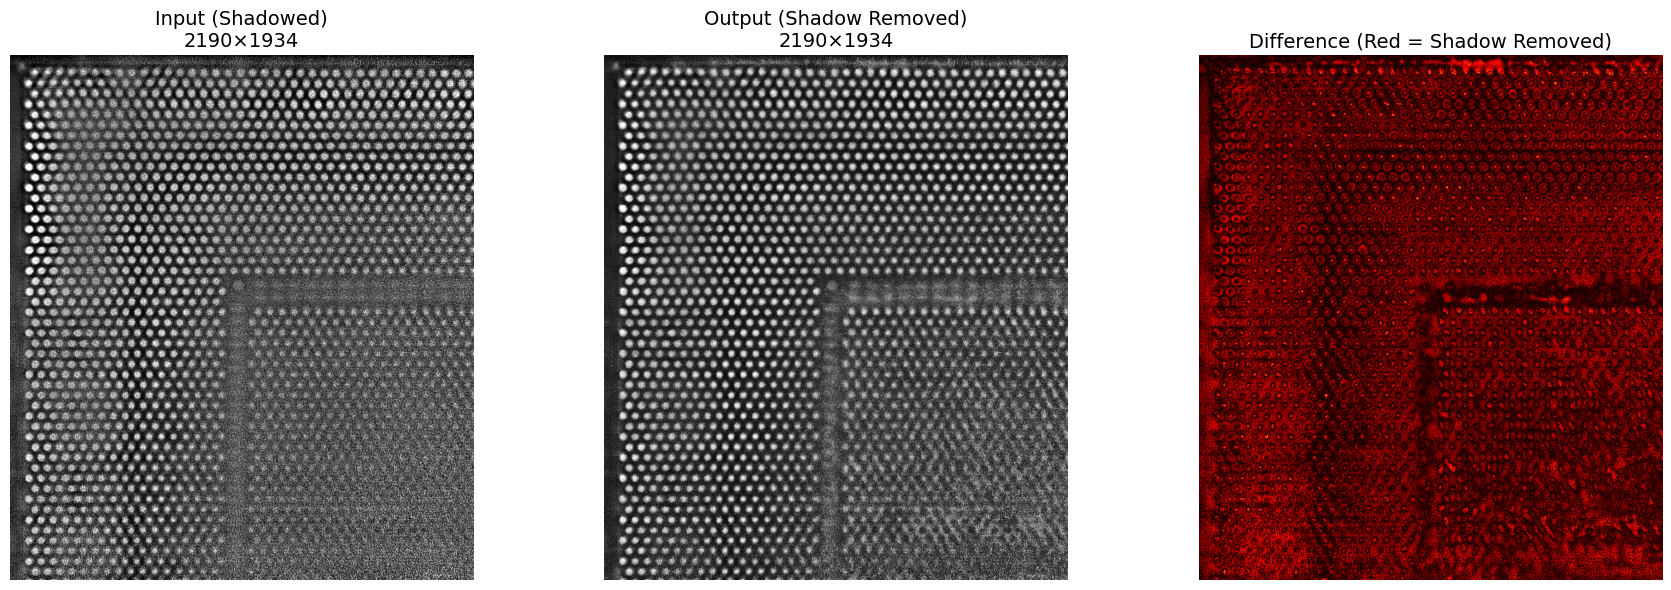

In [4]:
# ===========================
# TESTING CODE (GPU + TILING)
# ===========================

import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Use GPU (with tiling to avoid OOM)
model = UNet(in_channels=1).to(device)
model.load_state_dict(torch.load("final_tri_model_v2.pth", map_location=device))
model.eval()

print(f"✓ Model loaded on: {device.upper()}")

def test_image_tiled(image_path, save_path="result.png", tile_size=512, overlap=64):
    """
    Process large images in tiles to avoid GPU OOM.
    """
    # Read image
    img = cv2.imread(image_path, 0)
    if img is None:
        print(f"Cannot read image: {image_path}")
        return None
    
    original_h, original_w = img.shape
    print(f"Original size: {original_h} × {original_w}")
    
    # Pad to tile boundary
    pad_h = (tile_size - original_h % tile_size) % tile_size
    pad_w = (tile_size - original_w % tile_size) % tile_size
    
    img_padded = cv2.copyMakeBorder(
        img, 
        pad_h // 2, pad_h - pad_h // 2,
        pad_w // 2, pad_w - pad_w // 2,
        cv2.BORDER_REFLECT
    )
    
    padded_h, padded_w = img_padded.shape
    img_normalized = img_padded.astype(np.float32) / 255.0
    
    # Create output array
    result = np.zeros_like(img_normalized)
    weight_map = np.zeros_like(img_normalized)
    
    # Process tiles with overlap
    stride = tile_size - overlap
    n_tiles_h = max(1, (padded_h - overlap + stride - 1) // stride)
    n_tiles_w = max(1, (padded_w - overlap + stride - 1) // stride)
    
    print(f"Processing in {tile_size}×{tile_size} tiles (overlap={overlap}px)")
    print(f"Total tiles: {n_tiles_h} × {n_tiles_w} = {n_tiles_h * n_tiles_w}")
    
    tile_count = 0
    total_tiles = n_tiles_h * n_tiles_w
    
    for i in range(n_tiles_h):
        for j in range(n_tiles_w):
            tile_count += 1
            
            # Extract tile
            y_start = i * stride
            x_start = j * stride
            y_end = min(y_start + tile_size, padded_h)
            x_end = min(x_start + tile_size, padded_w)
            
            tile = img_normalized[y_start:y_end, x_start:x_end]
            
            # Pad tile to tile_size if needed
            tile_h, tile_w = tile.shape
            if tile_h < tile_size or tile_w < tile_size:
                tile = cv2.copyMakeBorder(
                    tile,
                    0, tile_size - tile_h,
                    0, tile_size - tile_w,
                    cv2.BORDER_REFLECT
                )
            
            # Process tile on GPU
            tile_tensor = torch.tensor(tile, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
            
            with torch.no_grad():
                tile_output = model(tile_tensor)
            
            tile_result = tile_output.squeeze().cpu().numpy()
            
            # Crop back to original tile size
            tile_result = tile_result[:tile_h, :tile_w]
            
            # Blend with feathering (avoid seams)
            weight = np.ones_like(tile_result)
            feather = overlap // 2
            
            # Feather edges
            if i > 0 and feather > 0:  # Top edge
                weight[:feather, :] = np.linspace(0, 1, feather)[:, None]
            if j > 0 and feather > 0:  # Left edge
                weight[:, :feather] *= np.linspace(0, 1, feather)[None, :]
            
            # Accumulate
            result[y_start:y_end, x_start:x_end] += tile_result * weight
            weight_map[y_start:y_end, x_start:x_end] += weight
            
            print(f"  Processed tile {tile_count}/{total_tiles}", end='\r')
    
    print("\n✓ Blending tiles...")
    
    # Normalize by weight
    result = result / (weight_map + 1e-8)
    
    # Remove padding
    result_cropped = result[
        pad_h // 2 : padded_h - (pad_h - pad_h // 2),
        pad_w // 2 : padded_w - (pad_w - pad_w // 2)
    ]
    
    # Convert to uint8
    result_cropped = np.clip(result_cropped * 255, 0, 255).astype(np.uint8)
    
    # Save results
    cv2.imwrite(save_path, result_cropped)
    comparison = np.hstack([img, result_cropped])
    cv2.imwrite(save_path.replace(".png", "_comparison.png"), comparison)
    print(f"✓ Saved to: {save_path}")
    
    # Display in Jupyter (resized for display)
    display_scale = min(1.0, 1200 / max(original_h, original_w))
    img_display = cv2.resize(img, None, fx=display_scale, fy=display_scale)
    result_display = cv2.resize(result_cropped, None, fx=display_scale, fy=display_scale)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    axes[0].imshow(img_display, cmap='gray', vmin=0, vmax=255)
    axes[0].set_title(f'Input (Shadowed)\n{original_h}×{original_w}', fontsize=14)
    axes[0].axis('off')
    
    axes[1].imshow(result_display, cmap='gray', vmin=0, vmax=255)
    axes[1].set_title(f'Output (Shadow Removed)\n{original_h}×{original_w}', fontsize=14)
    axes[1].axis('off')
    
    # Difference map
    diff = cv2.absdiff(img_display, result_display)
    axes[2].imshow(diff, cmap='hot', vmin=0, vmax=128)
    axes[2].set_title('Difference (Red = Shadow Removed)', fontsize=14)
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return result_cropped

# Test with GPU tiling
result = test_image_tiled(
    r"C:\Users\User\OneDrive\Documents\Shadow Removal\Shadow_Removal\image2.bmp",
    save_path="tri_result_v2.png",
    tile_size=512,
    overlap=64
)


## Run the code on image 1 as well 


C:\Users\User\AppData\Local\Temp\ipykernel_15444\3445153354.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("final_tri_model_v2.pth", m

✓ Model loaded on: CUDA
Original size: 728 × 1531
Processing in 512×512 tiles (overlap=64px)
Total tiles: 3 × 4 = 12
  Processed tile 12/12
✓ Blending tiles...
✓ Saved to: tri_result_v2.png


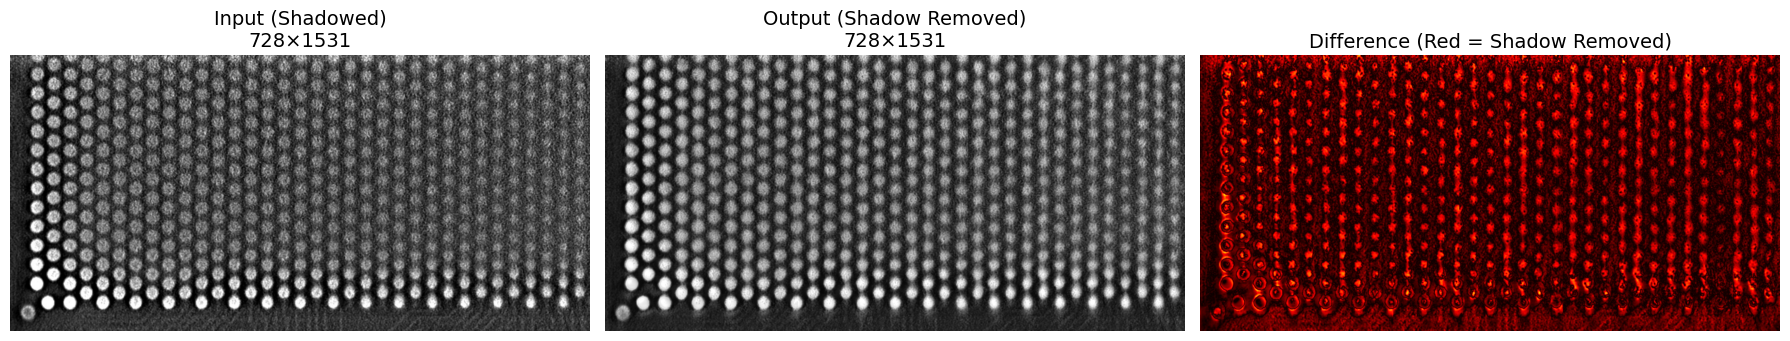

In [5]:
# ===========================
# TESTING CODE (GPU + TILING)
# ===========================

import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Use GPU (with tiling to avoid OOM)
model = UNet(in_channels=1).to(device)
model.load_state_dict(torch.load("final_tri_model_v2.pth", map_location=device))
model.eval()

print(f"✓ Model loaded on: {device.upper()}")

def test_image_tiled(image_path, save_path="result.png", tile_size=512, overlap=64):
    """
    Process large images in tiles to avoid GPU OOM.
    """
    # Read image
    img = cv2.imread(image_path, 0)
    if img is None:
        print(f"Cannot read image: {image_path}")
        return None
    
    original_h, original_w = img.shape
    print(f"Original size: {original_h} × {original_w}")
    
    # Pad to tile boundary
    pad_h = (tile_size - original_h % tile_size) % tile_size
    pad_w = (tile_size - original_w % tile_size) % tile_size
    
    img_padded = cv2.copyMakeBorder(
        img, 
        pad_h // 2, pad_h - pad_h // 2,
        pad_w // 2, pad_w - pad_w // 2,
        cv2.BORDER_REFLECT
    )
    
    padded_h, padded_w = img_padded.shape
    img_normalized = img_padded.astype(np.float32) / 255.0
    
    # Create output array
    result = np.zeros_like(img_normalized)
    weight_map = np.zeros_like(img_normalized)
    
    # Process tiles with overlap
    stride = tile_size - overlap
    n_tiles_h = max(1, (padded_h - overlap + stride - 1) // stride)
    n_tiles_w = max(1, (padded_w - overlap + stride - 1) // stride)
    
    print(f"Processing in {tile_size}×{tile_size} tiles (overlap={overlap}px)")
    print(f"Total tiles: {n_tiles_h} × {n_tiles_w} = {n_tiles_h * n_tiles_w}")
    
    tile_count = 0
    total_tiles = n_tiles_h * n_tiles_w
    
    for i in range(n_tiles_h):
        for j in range(n_tiles_w):
            tile_count += 1
            
            # Extract tile
            y_start = i * stride
            x_start = j * stride
            y_end = min(y_start + tile_size, padded_h)
            x_end = min(x_start + tile_size, padded_w)
            
            tile = img_normalized[y_start:y_end, x_start:x_end]
            
            # Pad tile to tile_size if needed
            tile_h, tile_w = tile.shape
            if tile_h < tile_size or tile_w < tile_size:
                tile = cv2.copyMakeBorder(
                    tile,
                    0, tile_size - tile_h,
                    0, tile_size - tile_w,
                    cv2.BORDER_REFLECT
                )
            
            # Process tile on GPU
            tile_tensor = torch.tensor(tile, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
            
            with torch.no_grad():
                tile_output = model(tile_tensor)
            
            tile_result = tile_output.squeeze().cpu().numpy()
            
            # Crop back to original tile size
            tile_result = tile_result[:tile_h, :tile_w]
            
            # Blend with feathering (avoid seams)
            weight = np.ones_like(tile_result)
            feather = overlap // 2
            
            # Feather edges
            if i > 0 and feather > 0:  # Top edge
                weight[:feather, :] = np.linspace(0, 1, feather)[:, None]
            if j > 0 and feather > 0:  # Left edge
                weight[:, :feather] *= np.linspace(0, 1, feather)[None, :]
            
            # Accumulate
            result[y_start:y_end, x_start:x_end] += tile_result * weight
            weight_map[y_start:y_end, x_start:x_end] += weight
            
            print(f"  Processed tile {tile_count}/{total_tiles}", end='\r')
    
    print("\n✓ Blending tiles...")
    
    # Normalize by weight
    result = result / (weight_map + 1e-8)
    
    # Remove padding
    result_cropped = result[
        pad_h // 2 : padded_h - (pad_h - pad_h // 2),
        pad_w // 2 : padded_w - (pad_w - pad_w // 2)
    ]
    
    # Convert to uint8
    result_cropped = np.clip(result_cropped * 255, 0, 255).astype(np.uint8)
    
    # Save results
    cv2.imwrite(save_path, result_cropped)
    comparison = np.hstack([img, result_cropped])
    cv2.imwrite(save_path.replace(".png", "_comparison.png"), comparison)
    print(f"✓ Saved to: {save_path}")
    
    # Display in Jupyter (resized for display)
    display_scale = min(1.0, 1200 / max(original_h, original_w))
    img_display = cv2.resize(img, None, fx=display_scale, fy=display_scale)
    result_display = cv2.resize(result_cropped, None, fx=display_scale, fy=display_scale)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    axes[0].imshow(img_display, cmap='gray', vmin=0, vmax=255)
    axes[0].set_title(f'Input (Shadowed)\n{original_h}×{original_w}', fontsize=14)
    axes[0].axis('off')
    
    axes[1].imshow(result_display, cmap='gray', vmin=0, vmax=255)
    axes[1].set_title(f'Output (Shadow Removed)\n{original_h}×{original_w}', fontsize=14)
    axes[1].axis('off')
    
    # Difference map
    diff = cv2.absdiff(img_display, result_display)
    axes[2].imshow(diff, cmap='hot', vmin=0, vmax=128)
    axes[2].set_title('Difference (Red = Shadow Removed)', fontsize=14)
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return result_cropped

# Test with GPU tiling
result = test_image_tiled(
    r"C:\Users\User\OneDrive\Documents\Shadow Removal\Shadow_Removal\image1.jpeg",
    save_path="tri_result_v2.png",
    tile_size=512,
    overlap=64
)


## Hybrid post processing 

Original size: 2190 × 1934
Step 1: Running U-Net model...
Original size: 2190 × 1934
Processing in 512×512 tiles (overlap=64px)
Total tiles: 6 × 5 = 30
  Processed tile 30/30
✓ Blending tiles...
✓ Saved to: temp_model_output.png


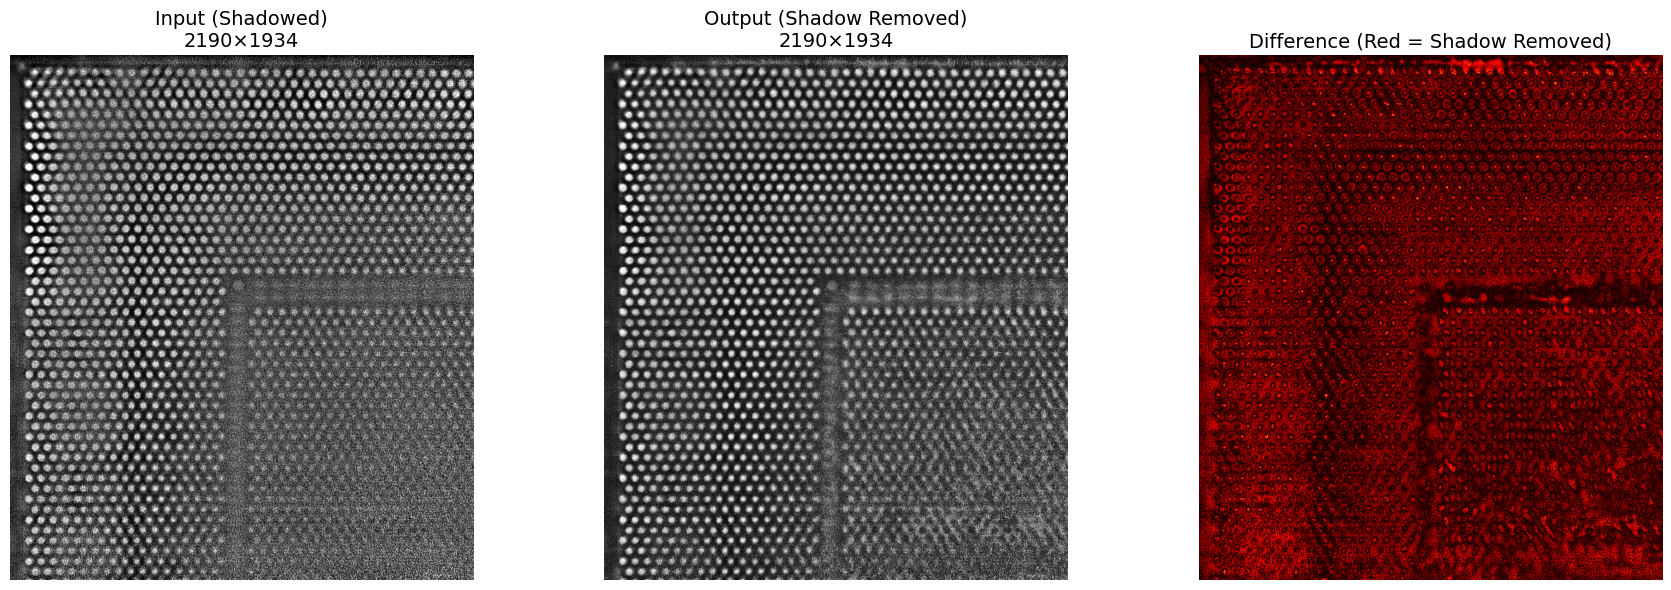


Step 2: Applying BGA post-processing (residual large closing)...


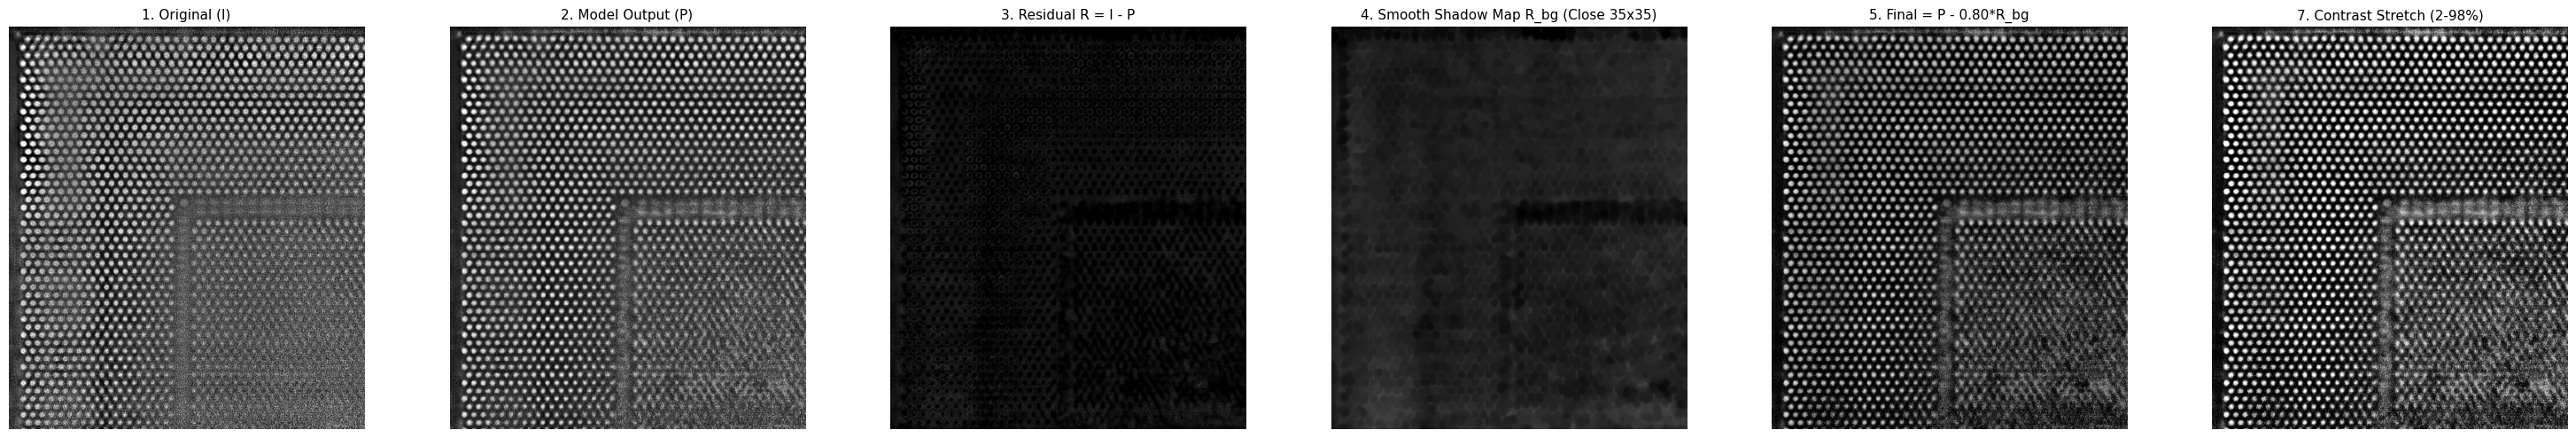

✓ Saved final result to: image2_bga_residual_close.png

 Brightness Analysis:
   Original:     88.8
   Model output: 80.5
   Final:        72.4
   Δ Final-Model: -8.1


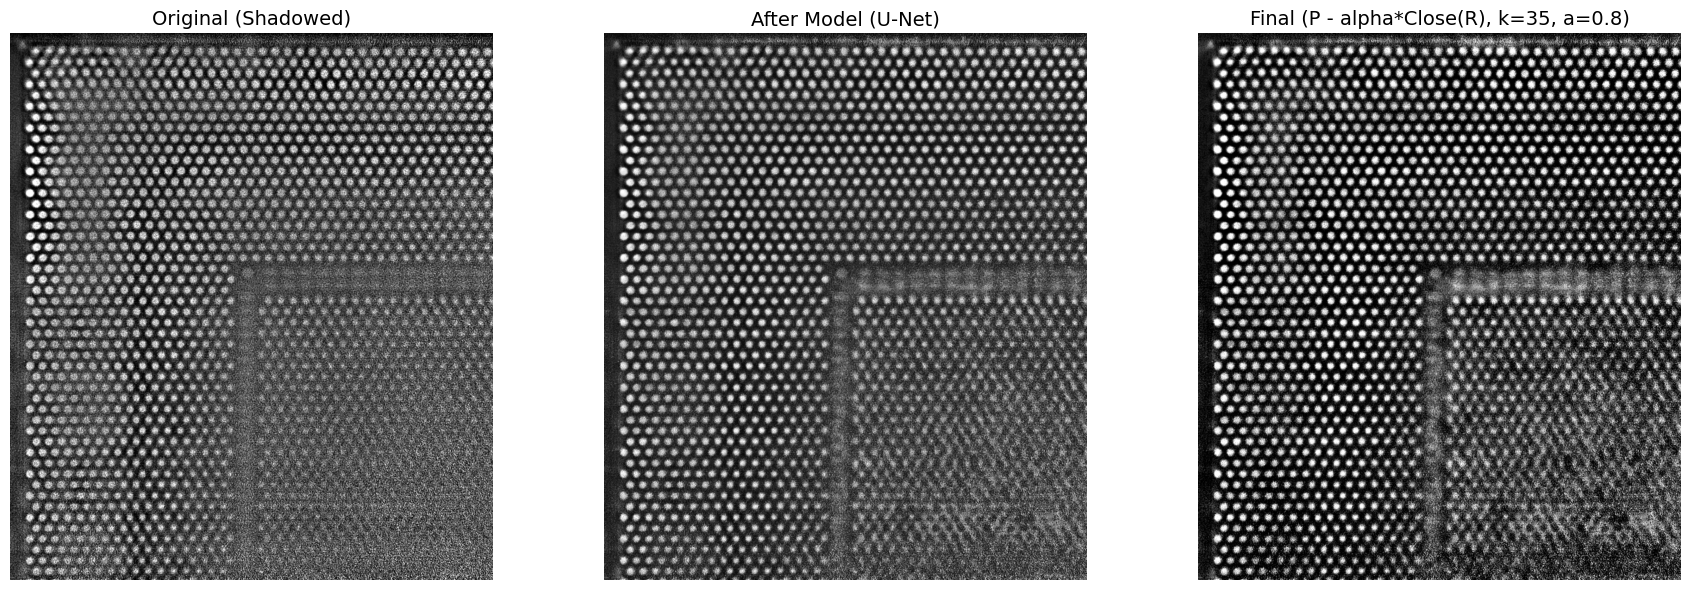

Original size: 728 × 1531
Step 1: Running U-Net model...
Original size: 728 × 1531
Processing in 512×512 tiles (overlap=64px)
Total tiles: 3 × 4 = 12
  Processed tile 12/12
✓ Blending tiles...
✓ Saved to: temp_model_output.png


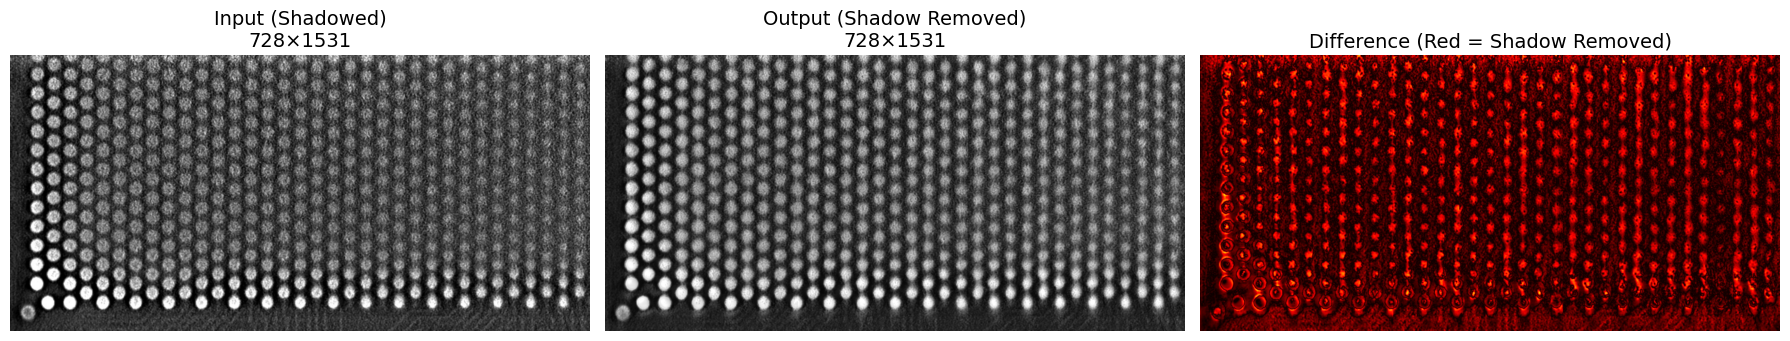


Step 2: Applying BGA post-processing (residual large closing)...


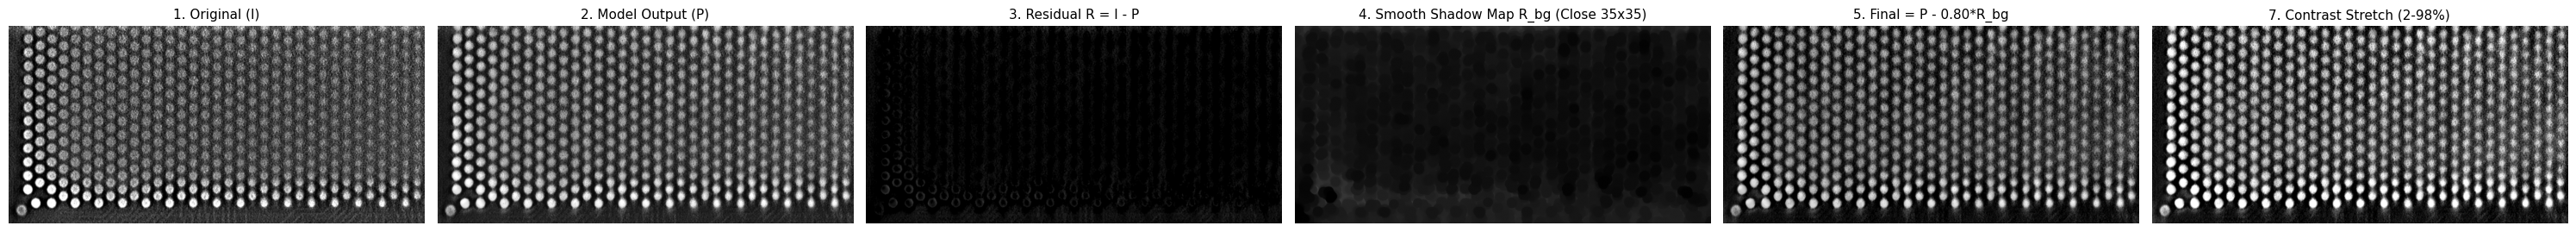

✓ Saved final result to: image2_bga_residual_close.png

 Brightness Analysis:
   Original:     78.2
   Model output: 81.5
   Final:        85.5
   Δ Final-Model: 4.0


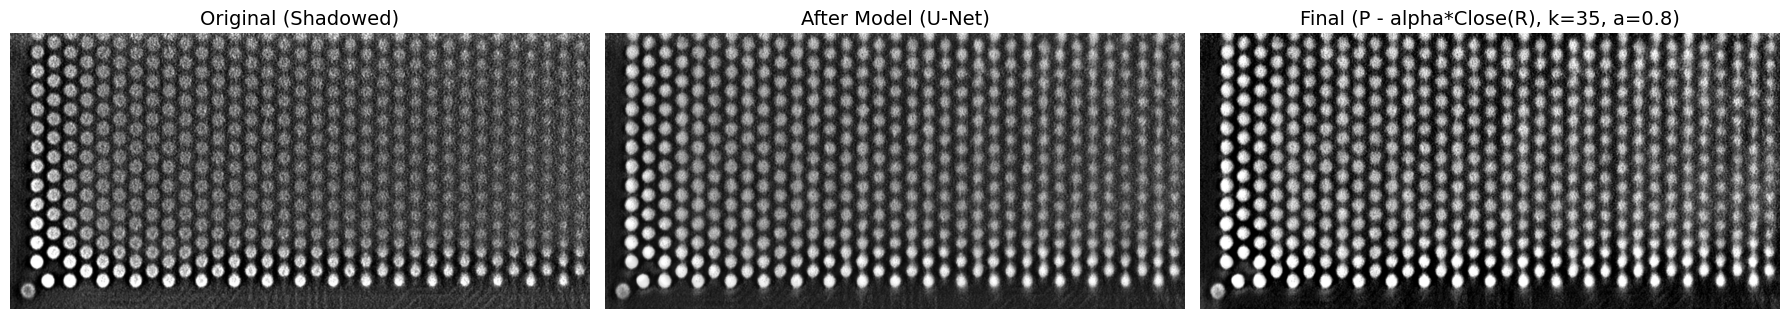

In [13]:
# ===========================
# BGA X-RAY SHADOW CLEANUP (MODEL + MORPHO RESIDUAL BACKGROUND)
# ===========================
# Goal:
# 1) Keep the U-Net output (P) as the base (so we don't reintroduce original shadows)
# 2) Compute residual R = I - P (what the model removed / struggled with)
# 3) Estimate the *smooth* leftover shadow field via LARGE morphological closing on R
# 4) Subtract that smooth field from the model output: Final = P - alpha * R_bg
# 5) Optional: gentle contrast stretch (very mild) + optional smoothing
#
# This is safer for BGA because:
# - We operate on a smooth "shadow field" (low-frequency) rather than doing top-hat/black-hat on the image
# - Large kernel is chosen bigger than solder-ball diameter -> avoids touching balls/voids
#

import cv2
import numpy as np
import matplotlib.pyplot as plt


# ---------------------------
# Utilities
# ---------------------------

def _ensure_uint8(img: np.ndarray) -> np.ndarray:
    if img is None:
        raise ValueError("Image is None.")
    if img.dtype == np.uint8:
        return img
    # If float in [0,1] or [0,255], map safely
    img_f = img.astype(np.float32)
    if img_f.max() <= 1.5:
        img_f = img_f * 255.0
    img_f = np.clip(img_f, 0, 255)
    return img_f.astype(np.uint8)

def _clip_sub(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    # Safe uint8 subtraction: a - b clipped at 0
    return cv2.subtract(a, b)

def _clip_add(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    return cv2.add(a, b)

def percentile_contrast_stretch(img: np.ndarray, p_low=2, p_high=98) -> np.ndarray:
    """Gentle contrast stretch. Use mild percentiles to avoid blowing out balls/voids."""
    img_u8 = _ensure_uint8(img)
    lo, hi = np.percentile(img_u8, (p_low, p_high))
    if hi <= lo + 1e-6:
        return img_u8
    out = (img_u8.astype(np.float32) - lo) * (255.0 / (hi - lo))
    out = np.clip(out, 0, 255).astype(np.uint8)
    return out

def show_steps_dict(steps: dict, figsize_per=5):
    n = len(steps)
    fig, axes = plt.subplots(1, n, figsize=(figsize_per*n, figsize_per))
    if n == 1:
        axes = [axes]
    for ax, (title, im) in zip(axes, steps.items()):
        ax.imshow(im, cmap="gray", vmin=0, vmax=255)
        ax.set_title(title, fontsize=11)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


# ---------------------------
# Main Post-Processing
# ---------------------------

def post_process_bga_shadow_cleanup(
    original_img: np.ndarray,
    model_output: np.ndarray,
    kernel_size: int = 35,
    alpha: float = 1.0,
    do_contrast_stretch: bool = True,
    stretch_p_low: float = 2,
    stretch_p_high: float = 98,
    do_smooth: bool = False,
    show_steps: bool = True
):
    """
    BGA X-ray shadow cleanup after U-Net using:
      R = I - P
      R_bg = LargeMorphClose(R)
      Final = P - alpha * R_bg

    Params:
    - kernel_size: choose > solder ball diameter in pixels. Typical: 31..45 for your resolution.
    - alpha: strength of removing estimated shadow field. Start 0.6..1.0. If it over-brightens, reduce.
    - do_contrast_stretch: mild stretching at the end (optional).
    - do_smooth: optional light Gaussian blur (3x3) to reduce tiny banding.
    """

    I = _ensure_uint8(original_img)
    P = _ensure_uint8(model_output)

    if I.shape != P.shape:
        raise ValueError(f"Shape mismatch: original {I.shape} vs model_output {P.shape}. "
                         f"Make sure model output is in original resolution.")

    steps = {}
    steps["1. Original (I)"] = I
    steps["2. Model Output (P)"] = P

    # Step A: Residual (what the model removed / where it differs)
    R = _clip_sub(I, P)
    steps["3. Residual R = I - P"] = R

    # Step B: Estimate smooth shadow field from residual using LARGE closing
    # Large elliptical kernel (bigger than solder ball diameter)
    k = int(kernel_size)
    if k % 2 == 0:
        k += 1  # enforce odd size
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))

    R_bg = cv2.morphologyEx(R, cv2.MORPH_CLOSE, kernel)
    steps[f"4. Smooth Shadow Map R_bg (Close {k}x{k})"] = R_bg

    # Step C: Subtract smooth shadow map from model output (NOT from original)
    # Use float math to apply alpha, then clip back
    P_f = P.astype(np.float32)
    Rbg_f = R_bg.astype(np.float32)
    final_f = P_f - alpha * Rbg_f
    final = np.clip(final_f, 0, 255).astype(np.uint8)
    steps[f"5. Final = P - {alpha:.2f}*R_bg"] = final

    # Optional smoothing
    if do_smooth:
        final = cv2.GaussianBlur(final, (3, 3), 0)
        steps["6. Optional Smooth (3x3 Gaussian)"] = final

    # Optional mild contrast stretching
    if do_contrast_stretch:
        final_cs = percentile_contrast_stretch(final, p_low=stretch_p_low, p_high=stretch_p_high)
        steps[f"7. Contrast Stretch ({stretch_p_low}-{stretch_p_high}%)"] = final_cs
        final = final_cs

    if show_steps:
        show_steps_dict(steps, figsize_per=5)

    return final, steps


# ---------------------------
# Full Test Wrapper (matches your pipeline style)
# ---------------------------

def test_with_bga_postprocessing(
    image_path: str,
    save_path: str = "result_bga_postprocessed.png",
    tile_size: int = 512,
    overlap: int = 64,
    kernel_size: int = 35,
    alpha: float = 1.0,
    do_contrast_stretch: bool = True,
    show_steps: bool = True
):
    """
    Full pipeline:
    1) Read original
    2) Run your tiled U-Net inference (test_image_tiled must exist in your code)
    3) Run BGA-safe morphological residual background subtraction
    4) Save and show comparison
    """
    # Read original
    I = cv2.imread(image_path, 0)
    if I is None:
        print(f" Cannot read: {image_path}")
        return None

    h, w = I.shape
    print(f"Original size: {h} × {w}")

    # Step 1: Model inference
    print("Step 1: Running U-Net model...")
    P = test_image_tiled(
        image_path,
        save_path="temp_model_output.png",
        tile_size=tile_size,
        overlap=overlap
    )
    P = _ensure_uint8(P)

    # Step 2: Post-processing using discussed plan
    print("\nStep 2: Applying BGA post-processing (residual large closing)...")
    final, steps = post_process_bga_shadow_cleanup(
        original_img=I,
        model_output=P,
        kernel_size=kernel_size,
        alpha=alpha,
        do_contrast_stretch=do_contrast_stretch,
        stretch_p_low=2,
        stretch_p_high=98,
        do_smooth=False,
        show_steps=show_steps
    )

    # Save final
    cv2.imwrite(save_path, final)
    print(f"✓ Saved final result to: {save_path}")

    # Brightness analysis (optional diagnostic)
    print(f"\n Brightness Analysis:")
    print(f"   Original:     {I.mean():.1f}")
    print(f"   Model output: {P.mean():.1f}")
    print(f"   Final:        {final.mean():.1f}")
    print(f"   Δ Final-Model: {final.mean() - P.mean():.1f}")

    # Final comparison
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(I, cmap='gray', vmin=0, vmax=255)
    axes[0].set_title('Original (Shadowed)', fontsize=14)
    axes[0].axis('off')

    axes[1].imshow(P, cmap='gray', vmin=0, vmax=255)
    axes[1].set_title('After Model (U-Net)', fontsize=14)
    axes[1].axis('off')

    axes[2].imshow(final, cmap='gray', vmin=0, vmax=255)
    axes[2].set_title(f'Final (P - alpha*Close(R), k={kernel_size}, a={alpha})', fontsize=14)
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    return final


## Run the function 
result = test_with_bga_postprocessing(
    r"C:\Users\User\OneDrive\Documents\Shadow Removal\Shadow_Removal\image2.bmp",
    save_path="image2_bga_residual_close.png",
    tile_size=512,
    overlap=64,
    kernel_size=35,
    alpha=0.8,
    do_contrast_stretch=True,
    show_steps=True
)


result = test_with_bga_postprocessing(
    r"C:\Users\User\OneDrive\Documents\Shadow Removal\Shadow_Removal\image1.jpeg",
    save_path="image2_bga_residual_close.png",
    tile_size=512,
    overlap=64,
    kernel_size=35,
    alpha=0.8,
    do_contrast_stretch=True,
    show_steps=True
)